# Exploratory Data Analysis (EDA)

<h3>The purpose of this notebook is to explore the e-commerce dataset and answer key business questions<br> that help understand sales performance,
customer behavior, product performance, website effectiveness, and refund patterns.<br>
This analysis serves as the foundation for subsequent SQL analysis and the Power BI dashboard.</h3>
<h4>The notebook answers the following business questions: </h4>
1. What is the overall revenue, gross profit, and gross margin of the business?<br>
2. How does revenue change over time? Are there any seasonal patterns?<br>
3. How many orders were placed and what is the Average Order Value(AOV)?<br>
4. Which products generate the highest revenue and profit?<br>
5. Which products have the highest refund rates and how much revenue is lost due to refunds?<br>
6. How effective is the website at converting visitors into customers?<br>
7. Which landing pages generate the highest traffic and conversion rates?<br>
Total: What are the key business insights and recommendations based on the analysis?<br>

In [61]:
import pandas as pd
import numpy as np

In [62]:
df_item_refunds=pd.read_csv('/Users/keneskenesbay/Documents/project_1/data/order_item_refunds.csv')
df_order_items=pd.read_csv('/Users/keneskenesbay/Documents/project_1/data/order_items.csv')
df_order=pd.read_csv('/Users/keneskenesbay/Documents/project_1/data/orders.csv')
df_products=pd.read_csv('/Users/keneskenesbay/Documents/project_1/data/products.csv')
df_websitepage_view=pd.read_csv('/Users/keneskenesbay/Documents/project_1/data/website_pageviews.csv')
df_website_sessions=pd.read_csv('/Users/keneskenesbay/Documents/project_1/data/website_sessions.csv')

<h4> 1-question </h4>

In [63]:
df_item_refunds['created_at']=pd.to_datetime(df_item_refunds['created_at'])
df_order_items['created_at']=pd.to_datetime(df_order_items['created_at'])
df_order['created_at']=pd.to_datetime(df_order['created_at'])
df_products['created_at']=pd.to_datetime(df_products['created_at'])
df_websitepage_view['created_at']=pd.to_datetime(df_websitepage_view['created_at'])
df_website_sessions['created_at']=pd.to_datetime(df_website_sessions['created_at'])

In [64]:
total_revenue=df_order['price_usd'].sum()
print('Total revenue:',total_revenue,'$')

Total revenue: 1938509.75 $


In [65]:
total_cogs=df_order['cogs_usd'].sum()
print('Total cogs:',total_cogs,'$')

Total cogs: 722370.25 $


In [66]:
total_profit=total_revenue-total_cogs
print('Gross profit:',total_profit,'$')

Gross profit: 1216139.5 $


In [68]:
margin=((total_profit/total_revenue)*100).round(2)
print('Gross margin:',margin)

Gross margin: 62.74


<h2> RESULTS 1</h2>

**Summary:** Total revenue: $1.94M with gross profit of $1.22M and gross margin of 62.74%. This indicates strong product-level profitability and solid financial foundation. <br>
**Recommendation:**  The 62.74% gross margin provides sufficient buffer to cover operating expenses and fund growth initiatives while maintaining healthy profitability across the business.


<h4> 2-question </h4>

In [69]:
df_order

,order_id,created_at,website_session_id,user_id,primary_product_id,items_purchased,price_usd,cogs_usd
0,1,2012-03-19 10:42:46,20,20,1,1,49.99,19.49
1,2,2012-03-19 19:27:37,104,104,1,1,49.99,19.49
2,3,2012-03-20 06:44:45,147,147,1,1,49.99,19.49
3,4,2012-03-20 09:41:45,160,160,1,1,49.99,19.49
4,5,2012-03-20 11:28:15,177,177,1,1,49.99,19.49
...,...,...,...,...,...,...,...,...
32308,32309,2015-03-19 03:58:12,472795,394255,1,1,49.99,19.49
32309,32310,2015-03-19 04:10:43,472798,394257,4,1,29.99,9.49
32310,32311,2015-03-19 05:27:28,472809,394268,2,2,89.98,31.98
32311,32312,2015-03-19 05:35:57,472814,394273,4,1,29.99,9.49


month_number
1     208746.53
2     221740.48
3     170036.35
4     112258.91
5     123698.48
6     117593.92
7     122880.82
8     127487.72
9     139303.27
10    160694.89
11    205687.82
12    228380.56
Name: price_usd, dtype: float64

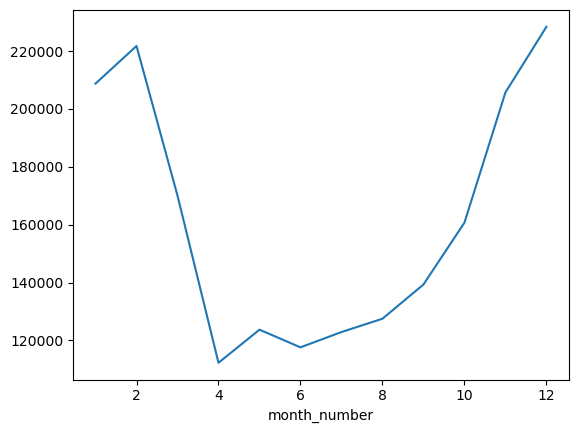

In [70]:
df_order['month_number']=df_order['created_at'].dt.month
month_revenue_summ=df_order.groupby('month_number')['price_usd'].sum().round(2)
month_revenue_summ=month_revenue_summ
month_revenue_summ.plot()
month_revenue_summ

In [71]:
monthly_avg_revenue=df_order.groupby('month_number')['price_usd'].sum().round(2)
monthly_avg_revenue=monthly_avg_revenue.mean().round(2)
print(monthly_avg_revenue,'$')

161542.48 $


In [72]:
best_month=month_revenue_summ.idxmax()
max_revenue=month_revenue_summ[best_month]
print('The best month by revenue',best_month,':',max_revenue)


The best month by revenue 12 : 228380.56


In [73]:
worst_month=month_revenue_summ.idxmin()
min_revenue=month_revenue_summ[worst_month]
print('The worst month by revenue',worst_month,':',min_revenue)

The worst month by revenue 4 : 112258.91


In [43]:
month_revenue_std=round(month_revenue_summ.std(),2)
print('The std of month revenue summ:',month_revenue_std,'$')


The std of month revenue summ: 43986.13 $


In [44]:
cv=round((month_revenue_std/monthly_avg_revenue)*100,2)
print('The CV is ->',cv)

The CV is -> 27.23


[Text(0, 0, '2999.4'), Text(0, 0, '17346.5'), Text(0, 0, '34193.2'), Text(0, 0, '74735.1'), Text(0, 0, '66377.3'), Text(0, 0, '88492.8'), Text(0, 0, '95241.5'), Text(0, 0, '143136'), Text(0, 0, '190771'), Text(0, 0, '247712'), Text(0, 0, '260237'), Text(0, 0, '376892'), Text(0, 0, '340376')]
year_quarter
2012Q1       2999.4$
2012Q2     17346.53$
2012Q3     34193.16$
2012Q4     74735.05$
2013Q1     66377.27$
2013Q2     88492.83$
2013Q3     95241.53$
2013Q4    143136.24$
2014Q1    190771.14$
2014Q2    247711.95$
2014Q3    260237.12$
2014Q4    376891.98$
2015Q1    340375.55$
Freq: Q-DEC, Name: price_usd, dtype: object


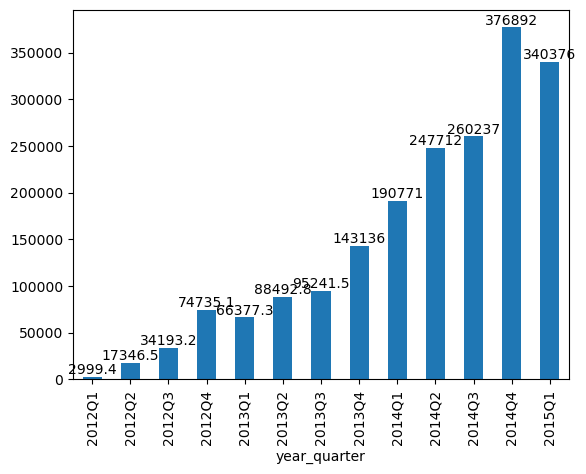

In [45]:
df_order["year_quarter"]=df_order["created_at"].dt.to_period("Q")
quarterly=(df_order.groupby("year_quarter")["price_usd"].sum()).round(2)
ax=quarterly.plot.bar()
print(ax.bar_label(ax.containers[0]))
quarterly=quarterly.astype(str)+'$'
print(quarterly)
quarterly.to_csv('quarterly_revenue.csv')

[Text(0, 0, '0'), Text(0, 0, '6.22475'), Text(0, 0, '-23.3174'), Text(0, 0, '-33.9795'), Text(0, 0, '10.1903'), Text(0, 0, '-4.93503'), Text(0, 0, '4.4959'), Text(0, 0, '3.74908'), Text(0, 0, '9.26799'), Text(0, 0, '15.3562'), Text(0, 0, '27.999'), Text(0, 0, '11.0326')]


,month,revenue,mom_growth
0,1,208746.53,NaN
1,2,221740.48,6.224750
2,3,170036.35,-23.317407
3,4,112258.91,-33.979464
4,5,123698.48,10.190345
5,6,117593.92,-4.935032
6,7,122880.82,4.495896
7,8,127487.72,3.749080
8,9,139303.27,9.267991
9,10,160694.89,15.356151


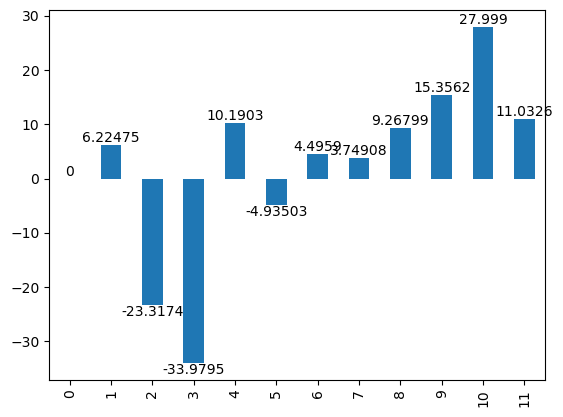

In [46]:
month_revenue_summ=df_order.groupby('month_number')['price_usd'].sum().round(2)
month_revenue_summ=month_revenue_summ.reset_index()
month_revenue_summ.columns=['month','revenue']
month_revenue_summ['mom_growth']=month_revenue_summ['revenue'].pct_change()*100
ax=month_revenue_summ['mom_growth'].plot.bar()
print(ax.bar_label(ax.containers[0]))
month_revenue_summ

In [47]:
margin=((total_profit/total_revenue)*100).round(2)
margin

np.float64(62.74)

In [48]:
print('---Margin---')
print('Total revenue for all period ->',total_revenue)
print('Total cogs for all period ->',total_cogs)
print('Total profit ->',total_profit)
print('Margin ->',margin)

---Margin---
Total revenue for all period -> 1938509.75
Total cogs for all period -> 722370.25
Total profit -> 1216139.5
Margin -> 62.74


[Text(0, 0, '3470'), Text(0, 0, '3587'), Text(0, 0, '2765'), Text(0, 0, '1893'), Text(0, 0, '2047'), Text(0, 0, '1972'), Text(0, 0, '2059'), Text(0, 0, '2161'), Text(0, 0, '2340'), Text(0, 0, '2688'), Text(0, 0, '3464'), Text(0, 0, '3867')]


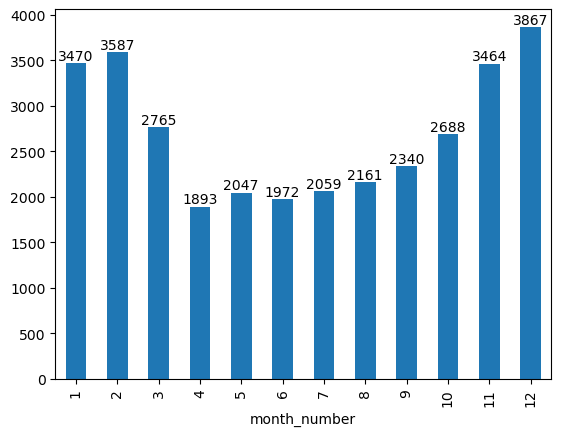

In [49]:
orders_by_month=df_order.groupby('month_number')['order_id'].count()
orders_by_month
ax=orders_by_month.plot.bar()
print(ax.bar_label(ax.containers[0]))
orders_by_month.to_csv('orders_by_month.csv')

<h2>RESULTS 2</h2>

**Summary:** Revenue follows a clear seasonal pattern, declining during Q2 and recovering strongly in Q4. This indicates demand is driven by seasonality rather than consistent year-round sales.<br>
**Recommendation:** Plan inventory purchases and marketing campaigns ahead of peak Q4 season, and consider promotional strategies to boost sales during weak Q2 periods to smooth revenue fluctuations.

<h4> 3-question</h4>

In [50]:
total_orders=df_order['order_id'].count()
print('Total orders:',total_orders)

Total orders: 32313


In [51]:
avg_order_value=(total_revenue/total_orders).round(2)
print('Average order value:',avg_order_value)

Average order value: 59.99


<h2> RESULTS 3 </h2>

**Summary:** 32,313 orders placed with average order value of $59.99. Stable purchase size provides predictable revenue.<br>
**Recommendation:** Implement product bundling and upselling strategies to increase average order value beyond current $59.99 baseline. 

<h4> 4-question</h4>

In [74]:
df_order_items

,order_item_id,created_at,order_id,product_id,is_primary_item,price_usd,cogs_usd
0,1,2012-03-19 10:42:46,1,1,1,49.99,19.49
1,2,2012-03-19 19:27:37,2,1,1,49.99,19.49
2,3,2012-03-20 06:44:45,3,1,1,49.99,19.49
3,4,2012-03-20 09:41:45,4,1,1,49.99,19.49
4,5,2012-03-20 11:28:15,5,1,1,49.99,19.49
...,...,...,...,...,...,...,...
40020,40021,2015-03-19 04:10:43,32310,4,1,29.99,9.49
40021,40022,2015-03-19 05:27:28,32311,2,1,59.99,22.49
40022,40023,2015-03-19 05:27:28,32311,4,0,29.99,9.49
40023,40024,2015-03-19 05:35:57,32312,4,1,29.99,9.49


In [75]:
df_products

,product_id,created_at,product_name
0,1,2012-03-19 08:00:00,The Original Mr. Fuzzy
1,2,2013-01-06 13:00:00,The Forever Love Bear
2,3,2013-12-12 09:00:00,The Birthday Sugar Panda
3,4,2014-02-05 10:00:00,The Hudson River Mini bear


In [76]:
df_product_sales=df_order_items.merge(df_products,on='product_id',how='left')
df_product_sales

,order_item_id,created_at_x,order_id,product_id,is_primary_item,price_usd,cogs_usd,created_at_y,product_name
0,1,2012-03-19 10:42:46,1,1,1,49.99,19.49,2012-03-19 08:00:00,The Original Mr. Fuzzy
1,2,2012-03-19 19:27:37,2,1,1,49.99,19.49,2012-03-19 08:00:00,The Original Mr. Fuzzy
2,3,2012-03-20 06:44:45,3,1,1,49.99,19.49,2012-03-19 08:00:00,The Original Mr. Fuzzy
3,4,2012-03-20 09:41:45,4,1,1,49.99,19.49,2012-03-19 08:00:00,The Original Mr. Fuzzy
4,5,2012-03-20 11:28:15,5,1,1,49.99,19.49,2012-03-19 08:00:00,The Original Mr. Fuzzy
...,...,...,...,...,...,...,...,...,...
40020,40021,2015-03-19 04:10:43,32310,4,1,29.99,9.49,2014-02-05 10:00:00,The Hudson River Mini bear
40021,40022,2015-03-19 05:27:28,32311,2,1,59.99,22.49,2013-01-06 13:00:00,The Forever Love Bear
40022,40023,2015-03-19 05:27:28,32311,4,0,29.99,9.49,2014-02-05 10:00:00,The Hudson River Mini bear
40023,40024,2015-03-19 05:35:57,32312,4,1,29.99,9.49,2014-02-05 10:00:00,The Hudson River Mini bear


Top products by units sold:
 product_name
The Original Mr. Fuzzy        24226
The Forever Love Bear          5796
The Hudson River Mini bear     5018
The Birthday Sugar Panda       4985
dtype: int64
[Text(0, 0, '24226'), Text(0, 0, '5796'), Text(0, 0, '5018'), Text(0, 0, '4985')]


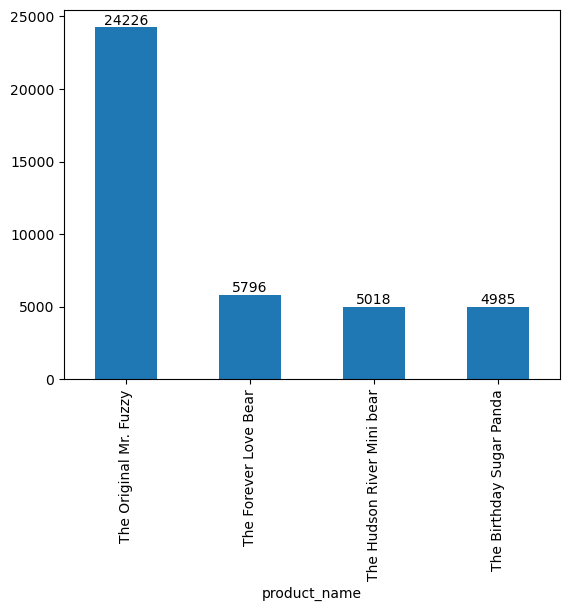

In [89]:
top_products_sold=df_product_sales.groupby('product_name').size().sort_values(ascending=False)
print('Top products by units sold:\n',top_products_sold)
ax_sold=top_products_sold.plot.bar()
print(ax_sold.bar_label(ax_sold.containers[0]))
top_products_sold=top_products_sold.to_frame()

In [78]:
df_product_sales['profit']=df_product_sales['price_usd']-df_product_sales['cogs_usd']
df_product_sales

,order_item_id,created_at_x,order_id,product_id,is_primary_item,price_usd,cogs_usd,created_at_y,product_name,profit
0,1,2012-03-19 10:42:46,1,1,1,49.99,19.49,2012-03-19 08:00:00,The Original Mr. Fuzzy,30.5
1,2,2012-03-19 19:27:37,2,1,1,49.99,19.49,2012-03-19 08:00:00,The Original Mr. Fuzzy,30.5
2,3,2012-03-20 06:44:45,3,1,1,49.99,19.49,2012-03-19 08:00:00,The Original Mr. Fuzzy,30.5
3,4,2012-03-20 09:41:45,4,1,1,49.99,19.49,2012-03-19 08:00:00,The Original Mr. Fuzzy,30.5
4,5,2012-03-20 11:28:15,5,1,1,49.99,19.49,2012-03-19 08:00:00,The Original Mr. Fuzzy,30.5
...,...,...,...,...,...,...,...,...,...,...
40020,40021,2015-03-19 04:10:43,32310,4,1,29.99,9.49,2014-02-05 10:00:00,The Hudson River Mini bear,20.5
40021,40022,2015-03-19 05:27:28,32311,2,1,59.99,22.49,2013-01-06 13:00:00,The Forever Love Bear,37.5
40022,40023,2015-03-19 05:27:28,32311,4,0,29.99,9.49,2014-02-05 10:00:00,The Hudson River Mini bear,20.5
40023,40024,2015-03-19 05:35:57,32312,4,1,29.99,9.49,2014-02-05 10:00:00,The Hudson River Mini bear,20.5


Top products by profit:
 product_name
The Original Mr. Fuzzy        738893.0
The Forever Love Bear         217350.0
The Birthday Sugar Panda      157027.5
The Hudson River Mini bear    102869.0
Name: profit, dtype: float64
[Text(0, 0, '738893'), Text(0, 0, '217350'), Text(0, 0, '157028'), Text(0, 0, '102869')]


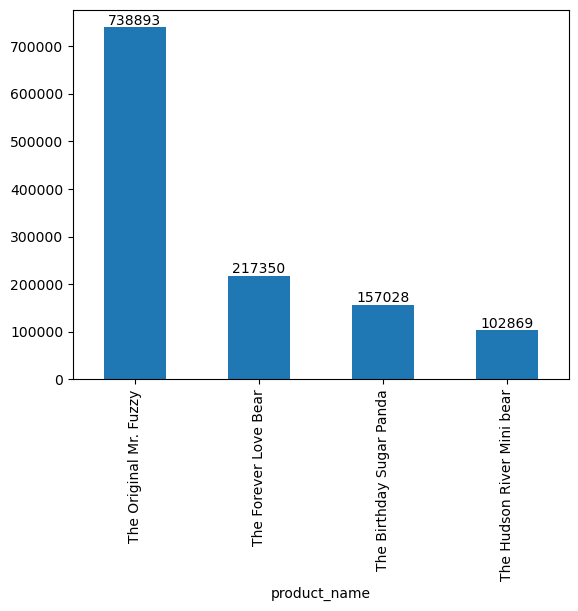

In [79]:
top_products_profit=df_product_sales.groupby('product_name')['profit'].sum().sort_values(ascending=False)
print('Top products by profit:\n',top_products_profit)
ax_profit=top_products_profit.plot.bar()
print(ax_profit.bar_label(ax_profit.containers[0]))
top_products_profit.to_csv('top_product_profit.csv')

Top products by revenue:
 product_name
The Original Mr. Fuzzy        1211057.74
The Forever Love Bear          347702.04
The Birthday Sugar Panda       229260.15
The Hudson River Mini bear     150489.82
Name: price_usd, dtype: float64
[Text(0, 0, '1.21106e+06'), Text(0, 0, '347702'), Text(0, 0, '229260'), Text(0, 0, '150490')]


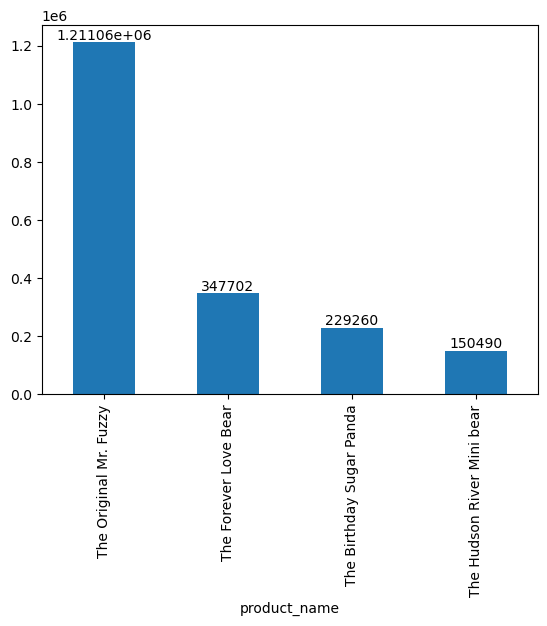

In [82]:
top_products_revenue=df_product_sales.groupby('product_name')['price_usd'].sum().sort_values(ascending=False)
print('Top products by revenue:\n',top_products_revenue)
ax_revenue=top_products_revenue.plot.bar()
print(ax_revenue.bar_label(ax_revenue.containers[0]))
top_products_revenue.to_csv('top_product_revenue.csv')
top_products_revenue=top_products_revenue.to_frame()

In [111]:
products_analysis=top_products_revenue.merge(top_products_profit,on='product_name',how='left')
products_analysis=products_analysis.merge(top_products_sold,on='product_name',how='left')
products_analysis=products_analysis.merge(product_lost_revenue,on='product_name',how='left')
products_analysis.columns=['revenue','profit','sold_units','refund']
products_analysis.to_csv('products_analysis.csv')
products_analysis

,revenue,profit,sold_units,refund
product_name,,,,
The Original Mr. Fuzzy,1211057.74,738893.0,24226,61837.63
The Forever Love Bear,347702.04,217350.0,5796,7738.71
The Birthday Sugar Panda,229260.15,157027.5,4985,13842.99
The Hudson River Mini bear,150489.82,102869.0,5018,1919.36


<h2> RESULTS 4 </h2>

**Summary:** The Original Mr. Fuzzy generates $1.21M revenue and $738.9k profit (61% of total). Other products are much weaker.<br>
**Recommendation:** Prioritize marketing budget and inventory investment for Mr. Fuzzy while conducting detailed analysis of <br>underperforming products to determine optimization or discontinuation strategy.


<h4> 5-question </h4>

In [97]:
df_product_sales

,order_item_id,created_at_x,order_id,product_id,is_primary_item,price_usd,cogs_usd,created_at_y,product_name,profit
0,1,2012-03-19 10:42:46,1,1,1,49.99,19.49,2012-03-19 08:00:00,The Original Mr. Fuzzy,30.5
1,2,2012-03-19 19:27:37,2,1,1,49.99,19.49,2012-03-19 08:00:00,The Original Mr. Fuzzy,30.5
2,3,2012-03-20 06:44:45,3,1,1,49.99,19.49,2012-03-19 08:00:00,The Original Mr. Fuzzy,30.5
3,4,2012-03-20 09:41:45,4,1,1,49.99,19.49,2012-03-19 08:00:00,The Original Mr. Fuzzy,30.5
4,5,2012-03-20 11:28:15,5,1,1,49.99,19.49,2012-03-19 08:00:00,The Original Mr. Fuzzy,30.5
...,...,...,...,...,...,...,...,...,...,...
40020,40021,2015-03-19 04:10:43,32310,4,1,29.99,9.49,2014-02-05 10:00:00,The Hudson River Mini bear,20.5
40021,40022,2015-03-19 05:27:28,32311,2,1,59.99,22.49,2013-01-06 13:00:00,The Forever Love Bear,37.5
40022,40023,2015-03-19 05:27:28,32311,4,0,29.99,9.49,2014-02-05 10:00:00,The Hudson River Mini bear,20.5
40023,40024,2015-03-19 05:35:57,32312,4,1,29.99,9.49,2014-02-05 10:00:00,The Hudson River Mini bear,20.5


In [98]:
df_item_refunds

,order_item_refund_id,created_at,order_item_id,order_id,refund_amount_usd
0,1,2012-04-06 11:32:43,57,57,49.99
1,2,2012-04-13 01:09:43,74,74,49.99
2,3,2012-04-15 07:03:48,71,71,49.99
3,4,2012-04-17 20:00:37,118,118,49.99
4,5,2012-04-22 20:53:49,116,116,49.99
...,...,...,...,...,...
1726,1727,2015-03-30 09:37:23,39950,32255,59.99
1727,1728,2015-03-30 21:33:51,39671,32049,49.99
1728,1729,2015-03-31 19:59:48,39729,32090,49.99
1729,1730,2015-04-01 03:54:48,39717,32079,59.99


In [99]:
df_refund_orders=df_product_sales.merge(df_item_refunds,on='order_item_id',how='inner')
df_refund_orders

,order_item_id,created_at_x,order_id_x,product_id,is_primary_item,price_usd,cogs_usd,created_at_y,product_name,profit,order_item_refund_id,created_at,order_id_y,refund_amount_usd
0,57,2012-03-31 02:32:43,57,1,1,49.99,19.49,2012-03-19 08:00:00,The Original Mr. Fuzzy,30.5,1,2012-04-06 11:32:43,57,49.99
1,71,2012-04-03 15:03:48,71,1,1,49.99,19.49,2012-03-19 08:00:00,The Original Mr. Fuzzy,30.5,3,2012-04-15 07:03:48,71,49.99
2,74,2012-04-03 19:09:43,74,1,1,49.99,19.49,2012-03-19 08:00:00,The Original Mr. Fuzzy,30.5,2,2012-04-13 01:09:43,74,49.99
3,116,2012-04-13 14:53:49,116,1,1,49.99,19.49,2012-03-19 08:00:00,The Original Mr. Fuzzy,30.5,5,2012-04-22 20:53:49,116,49.99
4,118,2012-04-15 09:00:37,118,1,1,49.99,19.49,2012-03-19 08:00:00,The Original Mr. Fuzzy,30.5,4,2012-04-17 20:00:37,118,49.99
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1726,39813,2015-03-17 01:31:53,32152,1,1,49.99,19.49,2012-03-19 08:00:00,The Original Mr. Fuzzy,30.5,1715,2015-03-22 02:31:53,32152,49.99
1727,39819,2015-03-17 05:34:49,32156,3,0,45.99,14.49,2013-12-12 09:00:00,The Birthday Sugar Panda,31.5,1724,2015-03-28 05:34:49,32156,45.99
1728,39860,2015-03-17 13:10:53,32191,1,1,49.99,19.49,2012-03-19 08:00:00,The Original Mr. Fuzzy,30.5,1722,2015-03-27 10:10:53,32191,49.99
1729,39947,2015-03-18 10:11:08,32252,3,1,45.99,14.49,2013-12-12 09:00:00,The Birthday Sugar Panda,31.5,1731,2015-04-01 18:11:08,32252,45.99


Top refund products:
 product_name
The Original Mr. Fuzzy        1237
The Birthday Sugar Panda       301
The Forever Love Bear          129
The Hudson River Mini bear      64
dtype: int64
Axes(0.22375,0.11;0.5775x0.77)


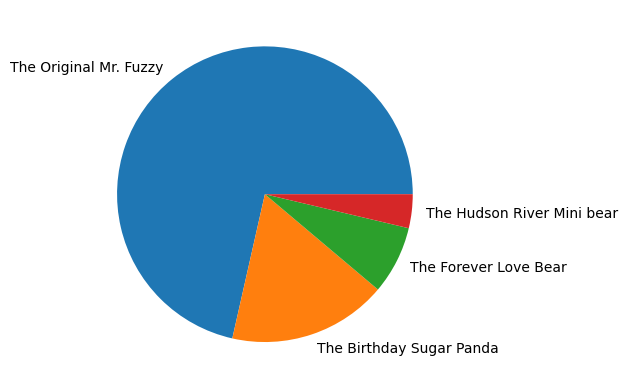

In [101]:
top_refund_products=df_refund_orders.groupby('product_name').size().sort_values(ascending=False)
print('Top refund products:\n',top_refund_products)
ax_refund=top_refund_products.plot.pie()
print(ax_refund)

In [102]:
product_lost_revenue=df_refund_orders.groupby('product_name')['price_usd'].sum().sort_values(ascending=False)
print('Top products by lost revenue:\n',product_lost_revenue)
product_lost_revenue.to_csv('product_lost_revenue.csv')


Top products by lost revenue:
 product_name
The Original Mr. Fuzzy        61837.63
The Birthday Sugar Panda      13842.99
The Forever Love Bear          7738.71
The Hudson River Mini bear     1919.36
Name: price_usd, dtype: float64


In [103]:
total_lost_revenue=df_refund_orders['price_usd'].sum()
print('Total lost revenue due refunds:',total_lost_revenue,'$')


Total lost revenue due refunds: 85338.69 $


<h2> RESULTS 5 </h2>

**Summary:** Lost $85,338 to refunds. The Original Mr. Fuzzy has 1,237 refunds and lost $61,838—the highest by far.<br>
**Recommendation:** Investigate quality control and product description accuracy for Mr. Fuzzy immediately,<br> as reducing refund rate by 2-3% would save $30-45k annually.

<h4>6-question </h4>

In [ ]:
df_website_sessions

In [ ]:
df_order

In [ ]:
df_website_orders=df_website_sessions.merge(df_order,on='website_session_id',how='left')
df_website_orders

In [ ]:
total_sessions=df_website_orders['website_session_id'].count()
print('Total sessions:',total_sessions)

In [ ]:
total_orders=df_website_orders['order_id'].count()
print('Total orders:',total_orders)

In [ ]:
conversation_rate=((total_orders/total_sessions)*100).round(2)
print('conversation rate:',conversation_rate)

In [ ]:
website_sources=df_website_orders.groupby('utm_source').agg(
    sessions=('website_session_id','nunique'),
    orders=('order_id','nunique'))
website_sources['conversion_rate']=((website_sources['orders']/website_sources['sessions'])*100).round(2)
website_sources.sort_values(by='conversion_rate',ascending=False)

In [ ]:
ax_conversion_rate=website_sources['conversion_rate'].plot.bar()
print(ax_conversion_rate.bar_label(ax_conversion_rate.containers[0]))

In [ ]:
website_sources.sort_values(by='sessions',ascending=False)
ax_sources=website_sources['sessions'].plot.bar()
print(ax_sources.bar_label(ax_sources.containers[0]))

<h2> RESULTS 6</h2>

**Summary:** Overall conversion is 6.83% (32k orders from 472k sessions). bsearch performs best at 7.19%, socialbook worst at 3.21%.<br>
**Recommendation:** Shift advertising budget from low-performing channels to bsearch and gsearch, and conduct A/B testing to improve <br>overall site conversion rate to 7-8%.

<h4>7-question</h4>

In [ ]:
display(df_websitepage_view,df_order)

In [ ]:
landing_pageview=df_websitepage_view.sort_values('created_at').drop_duplicates('website_session_id')
landing_pageview

In [ ]:
landing_page_order=landing_pageview.merge(df_order[['website_session_id','order_id']],on='website_session_id',how='left')
landing_page_order.head(10)

In [ ]:
sessions=landing_page_order.groupby('pageview_url').size()
sessions

In [ ]:
orders=landing_page_order.groupby('pageview_url')['order_id'].count()
orders

In [ ]:
landing_page_stats=pd.concat([sessions,orders],axis=1)
landing_page_stats.columns=['sessions','orders']
landing_page_stats

In [ ]:
landing_page_stats['conversion_rate']=((landing_page_stats['orders']/landing_page_stats['sessions'])*100).round(2)
landing_page_stats=landing_page_stats.sort_values(['conversion_rate'],ascending=False)
ax_page_conv=landing_page_stats['conversion_rate'].plot.bar()
print(landing_page_stats)
print(ax_page_conv.bar_label(ax_page_conv.containers[0]))
landing_page_stats.to_csv('landing_page_stats.csv')

<h2> RESULTS 7 </h2>

**Summary:** /lander-5 converts best at 10.17%. /lander-2 drives most traffic (131k) with 7.72% conversion. /lander-3 is terrible at 3.39%.<br>
**Recommendation:** Scale traffic allocation to /lander-5, completely redesign or remove /lander-3, and replicate /lander-5's successful <br>elements across other landing pages.

<h2> TOTAL INSIGHTS & RECOMMENDATIONS </h2>

**Key Findings:**
- Strong financials: $1.94M revenue, $1.22M profit, 62.74% margin
- Critical issue: Mr. Fuzzy drives 61% of profit (over-concentration risk)
- Refund rate eroding $85.3k annually (4.4% of revenue) — urgent quality review needed
- Conversion underperformance: 6.83% overall vs. bsearch 7.19% and socialbook 3.21%
- Landing page gap: /lander-5 converts at 10.17% vs. /lander-3 at 3.39%

**Recommendations:**
1. Reduce Mr. Fuzzy refunds (72% of losses) through quality control audit
2. Shift ad budget from socialbook to bsearch (+0.98% conversion potential)
3. Scale /lander-5 design across site; remove /lander-3
4. Implement product bundling to boost $59.99 AOV
5. Plan inventory around Q2 dip and Q4 peak seasonality

**Financial Impact:** 1-2% conversion gain + refund reduction = $250k-400k additional annual profit